In [2]:
# ==========================================
# ЯЧЕЙКА 1: Импорт библиотек (в начале notebook)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import os

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = ['Arial']

# Создаем папку для сохранения графиков, если её нет
output_dir = "dashboard_outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Создана папка: {output_dir}")
else:
    print(f"✅ Папка {output_dir} уже существует")

✅ Папка dashboard_outputs уже существует


In [3]:
# ==========================================
# ЯЧЕЙКА 2: Загрузка и проверка данных
# ==========================================
file_path = "customer_shopping_data.csv"
df = pd.read_csv(file_path)

print("=== ПЕРВИЧНЫЙ ОСМОТР ДАННЫХ ===")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nНазвания столбцов:")
print(df.columns.tolist())
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о типах данных:")
print(df.info())

=== ПЕРВИЧНЫЙ ОСМОТР ДАННЫХ ===
Размер датасета: 99457 строк, 9 столбцов

Названия столбцов:
['invoice_no', 'customer_id', 'gender', 'age', 'category', 'revenue', 'payment_method', 'invoice_date', 'shopping_mall']

Первые 5 строк:


,invoice_no,customer_id,gender,age,category,revenue,payment_method,invoice_date,shopping_mall
0,I192911,C642829,Female,66,Food & Beverage,89.02,Credit Card,2021-01-01,Metrocity
1,I235671,C196703,Female,45,Clothing,1789.32,Cash,2021-01-01,Metrocity
2,I371949,C260427,Male,50,Toys,413.73,Credit Card,2021-01-01,Metrocity
3,I246142,C209273,Female,59,Souvenir,129.19,Cash,2021-01-01,Viaport Outlet
4,I312847,C535517,Male,60,Souvenir,67.45,Credit Card,2021-01-01,Cevahir AVM



Информация о типах данных:
<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   revenue         99457 non-null  float64
 6   payment_method  99457 non-null  str    
 7   invoice_date    99457 non-null  str    
 8   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 12.2 MB
None


In [4]:
# ==========================================
# ЯЧЕЙКА 3: Проверка качества данных
# ==========================================
print("=== ПРОВЕРКА КАЧЕСТВА ДАННЫХ ===")

# Пропуски
print("\n1. Пропуски в данных:")
print(df.isnull().sum())

# Дубликаты
print(f"\n2. Полные дубликаты строк: {df.duplicated().sum()}")

# Уникальность клиентов
print(f"\n3. Уникальных invoice_no: {df['invoice_no'].nunique()}")
print(f"   Уникальных customer_id: {df['customer_id'].nunique()}")
print(f"   → Каждый клиент встречается: {len(df) / df['customer_id'].nunique():.2f} раз")

# Проверка на отрицательные значения
print("\n4. Отрицательные значения:")
print(f"   age < 0: {(df['age'] < 0).sum()}")
print(f"   revenue <= 0: {(df['revenue'] <= 0).sum()}")

# Выбросы в price и revenue
print("\n5. Выбросы в выручке (revenue):")
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1
outliers_price = df[(df['revenue'] < Q1 - 1.5*IQR) | (df['revenue'] > Q3 + 1.5*IQR)]
print(f"   Количество выбросов: {len(outliers_price)} ({len(outliers_price)/len(df)*100:.2f}%)")

=== ПРОВЕРКА КАЧЕСТВА ДАННЫХ ===

1. Пропуски в данных:
invoice_no        0
customer_id       0
gender            0
age               0
category          0
revenue           0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

2. Полные дубликаты строк: 0

3. Уникальных invoice_no: 99457
   Уникальных customer_id: 99457
   → Каждый клиент встречается: 1.00 раз

4. Отрицательные значения:
   age < 0: 0
   revenue <= 0: 0

5. Выбросы в выручке (revenue):
   Количество выбросов: 375 (0.38%)


In [5]:
# ==========================================
# ЯЧЕЙКА 4: Подготовка данных
# ==========================================
print("=== ПОДГОТОВКА ДАННЫХ ===")

# Парсинг даты
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%Y-%m-%d')

# Временные признаки
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month
df['day_of_week'] = df['invoice_date'].dt.day_name()
df['day_of_week_num'] = df['invoice_date'].dt.dayofweek
df['year_month'] = df['invoice_date'].dt.to_period('M').astype(str)

# Возрастные группы (ЯВНОЕ СОЗДАНИЕ)
df['age_group'] = pd.cut(df['age'], 
                          bins=[0, 25, 35, 50, 100], 
                          labels=['18-25', '26-35', '36-50', '50+'],
                          right=True)

# Сортировка по дате
df = df.sort_values(by='invoice_date')

print("✓ Данные подготовлены")
print(f"\nРаспределение по возрастным группам:")
print(df['age_group'].value_counts().sort_index())

print("\nПервые 3 строки с новыми признаками:")
display(df[['invoice_no', 'invoice_date', 'revenue', 'year', 'month', 'day_of_week', 'day_of_week_num', 'age_group']].head(3))


=== ПОДГОТОВКА ДАННЫХ ===
✓ Данные подготовлены

Распределение по возрастным группам:
age_group
18-25    15359
26-35    19059
36-50    28938
50+      36101
Name: count, dtype: int64

Первые 3 строки с новыми признаками:


,invoice_no,invoice_date,revenue,year,month,day_of_week,day_of_week_num,age_group
0,I192911,2021-01-01,89.02,2021,1,Friday,4,50+
76,I256461,2021-01-01,52.20,2021,1,Friday,4,50+
75,I983410,2021-01-01,409.06,2021,1,Friday,4,50+


In [75]:
# Сохраняем очищенные данные в файл
df.to_csv('customer_shopping_data_clean.csv', index=False, sep=',', encoding='utf-8-sig')

In [8]:
# ==========================================
# ЯЧЕЙКА 5: БАЗОВЫЕ МЕТРИКИ (адаптированные под специфику)
# ==========================================
print("=== КЛЮЧЕВЫЕ МЕТРИКИ ===")

total_revenue = df['revenue'].sum()
total_customers = df['customer_id'].nunique()
avg_purchase = df['revenue'].mean()
median_purchase = df['revenue'].median()

print(f"Общая выручка: {total_revenue:,.2f}")
print(f"Всего клиентов: {total_customers:,}")
print(f"Всего транзакций: {len(df):,}")
print(f"Средний чек: {avg_purchase:,.2f}")
print(f"Медианный чек: {median_purchase:,.2f}")
print(f"\n️  ВАЖНО: Каждый клиент совершил только ОДНУ покупку")
print("→ RFM-анализ и анализ повторных покупок НЕВОЗМОЖЕН")
print("→ Фокус на сегментации по сумме покупки и демографии")

=== КЛЮЧЕВЫЕ МЕТРИКИ ===
Общая выручка: 120,414,175.84
Всего клиентов: 99,457
Всего транзакций: 99,457
Средний чек: 1,210.72
Медианный чек: 971.68

️  ВАЖНО: Каждый клиент совершил только ОДНУ покупку
→ RFM-анализ и анализ повторных покупок НЕВОЗМОЖЕН
→ Фокус на сегментации по сумме покупки и демографии


## ⚠️ Примечание по RFM-анализу

**Проверка данных показала критическую особенность датасета:**

    
### Почему RFM неприменим?

RFM-анализ требует **повторных покупок** от одного клиента для расчета:
- **Recency** (давность последней покупки) — требует истории покупок
- **Frequency** (частота покупок) — требует минимум 2+ транзакций
- **Monetary** (суммарная выручка) — работает, но теряет смысл без F и R

В нашем датасете **каждый customer_id встречается ровно один раз**, что означает:
- Все клиенты имеют `frequency = 1.0`
- Невозможно рассчитать Recency (нет истории)
- Сегментация по RFM становится бессмысленной

### Альтернативный подход

Вместо RFM мы используем **сегментацию по сумме покупки** (см. Ячейку 7), которая:
- Делит клиентов на 4 группы: Low, Medium, High, Premium
- Основана на квантилях выручки
- Позволяет анализировать профили разных сегментов (возраст, категории, ТЦ)

### Ограничения датасета

Этот датасет представляет собой **кросс-секционный срез** транзакций, а не панельные данные. Для полноценного RFM-анализа необходимо:
- Данные о повторных покупках клиентов
- История транзакций за длительный период
- Идентификация клиентов между визитами

=== СЕГМЕНТАЦИЯ ПО СУММЕ ПОКУПКИ ===

Профили сегментов:


,customers,avg_age,avg_revenue,median_revenue,top_category,top_mall
purchase_segment,,,,,,
Low,24868,43.38,131.79,122.19,Food & Beverage,Kanyon
Medium,24862,43.49,577.49,558.19,Cosmetics,Mall of Istanbul
High,24863,43.37,1490.41,1489.37,Clothing,Mall of Istanbul
Premium,24864,43.46,2643.31,2557.30,Clothing,Mall of Istanbul


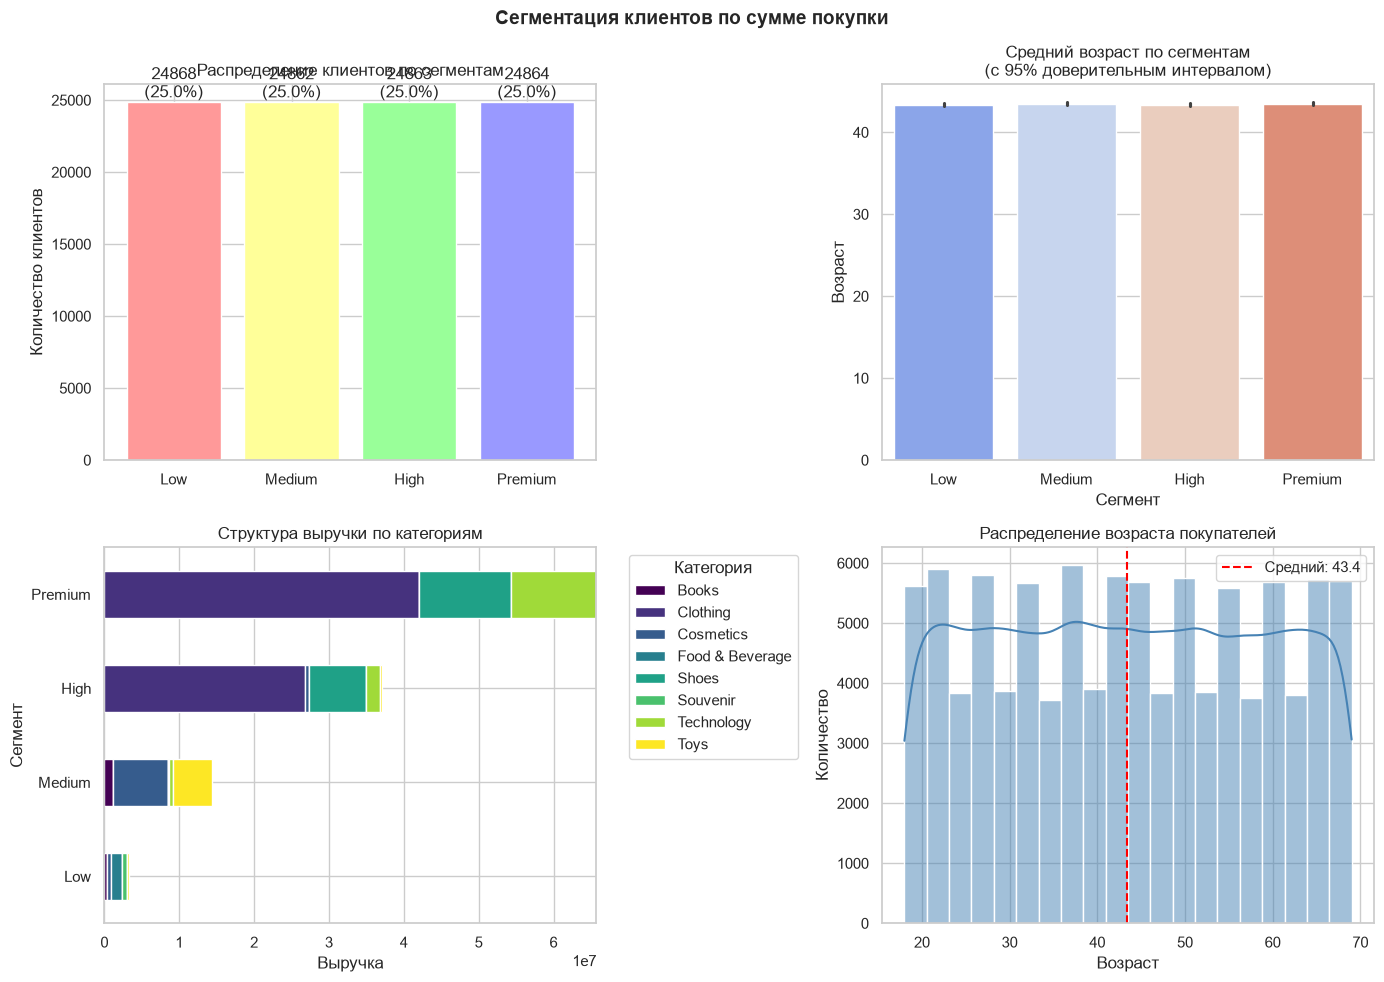

In [9]:
# ==========================================
# ЯЧЕЙКА 6: СЕГМЕНТАЦИЯ КЛИЕНТОВ ПО СУММЕ ПОКУПКИ
# ==========================================
print("=== СЕГМЕНТАЦИЯ ПО СУММЕ ПОКУПКИ ===")

# Создаем сегменты через квантили
df['purchase_segment'] = pd.qcut(df['revenue'], q=4, labels=['Low', 'Medium', 'High', 'Premium'])

segment_profile = df.groupby('purchase_segment').agg(
    customers=('customer_id', 'nunique'),
    avg_age=('age', 'mean'),
    avg_revenue=('revenue', 'mean'),
    median_revenue=('revenue', 'median'),
    top_category=('category', lambda x: x.mode().iloc[0]),
    top_mall=('shopping_mall', lambda x: x.mode().iloc[0])
).round(2)

print("\nПрофили сегментов:")
display(segment_profile)

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сегментация клиентов по сумме покупки', fontsize=14, fontweight='bold')

# 1. Распределение по сегментам
segment_counts = df['purchase_segment'].value_counts().sort_index()
colors = ['#ff9999', '#ffff99', '#99ff99', '#9999ff']
axes[0, 0].bar(segment_counts.index, segment_counts.values, color=colors)
axes[0, 0].set_title('Распределение клиентов по сегментам')
axes[0, 0].set_ylabel('Количество клиентов')
for i, v in enumerate(segment_counts.values):
    axes[0, 0].text(i, v, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom')

# 2. Средний возраст по сегментам
sns.barplot(data=df, x='purchase_segment', y='age', ax=axes[0, 1], 
            errorbar=('ci', 95), palette='coolwarm')
axes[0, 1].set_title('Средний возраст по сегментам\n(с 95% доверительным интервалом)')
axes[0, 1].set_xlabel('Сегмент')
axes[0, 1].set_ylabel('Возраст')

# 3. Выручка по категориям в разрезе сегментов
category_segment = df.groupby(['purchase_segment', 'category'])['revenue'].sum().unstack(fill_value=0)
category_segment.plot(kind='barh', stacked=True, ax=axes[1, 0], colormap='viridis')
axes[1, 0].set_title('Структура выручки по категориям')
axes[1, 0].set_xlabel('Выручка')
axes[1, 0].set_ylabel('Сегмент')
axes[1, 0].legend(title='Категория', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Распределение возрастов
sns.histplot(data=df, x='age', bins=20, ax=axes[1, 1], kde=True, color='steelblue')
axes[1, 1].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Средний: {df["age"].mean():.1f}')
axes[1, 1].set_title('Распределение возраста покупателей')
axes[1, 1].set_xlabel('Возраст')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].legend()

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "01.png"), dpi=300, bbox_inches='tight', facecolor='white')

=== АНАЛИЗ ТОРГОВЫХ ЦЕНТРОВ ===

Анализ по торговым центрам:


,unique_customers,total_revenue,avg_purchase,median_purchase,std_purchase,top_category
shopping_mall,,,,,,
Mall of Istanbul,19943,24244379.29,1215.68,978.34,1016.05,Clothing
Kanyon,19823,23927151.13,1207.04,967.10,1014.44,Clothing
Metrocity,15011,18257010.68,1216.24,976.83,1018.73,Clothing
Metropol AVM,10161,12193572.65,1200.04,971.92,1004.42,Clothing
Istinye Park,9781,11817269.10,1208.19,963.48,1015.47,Clothing
Zorlu Center,5075,6177087.51,1217.16,977.16,1016.25,Clothing
Cevahir AVM,4991,6011676.79,1204.50,969.04,1016.69,Clothing
Viaport Outlet,4914,5968858.09,1214.66,982.60,1013.53,Clothing
Forum Istanbul,4947,5956389.33,1204.04,947.88,1014.93,Clothing



=== СТАТИСТИЧЕСКАЯ ПРОВЕРКА ===
ANOVA тест: различаются ли средние чеки между торговыми центрами?

F-статистика: 0.3680
P-value: 9.5065e-01
✗ Статистически значимых различий НЕТ (p >= 0.05)


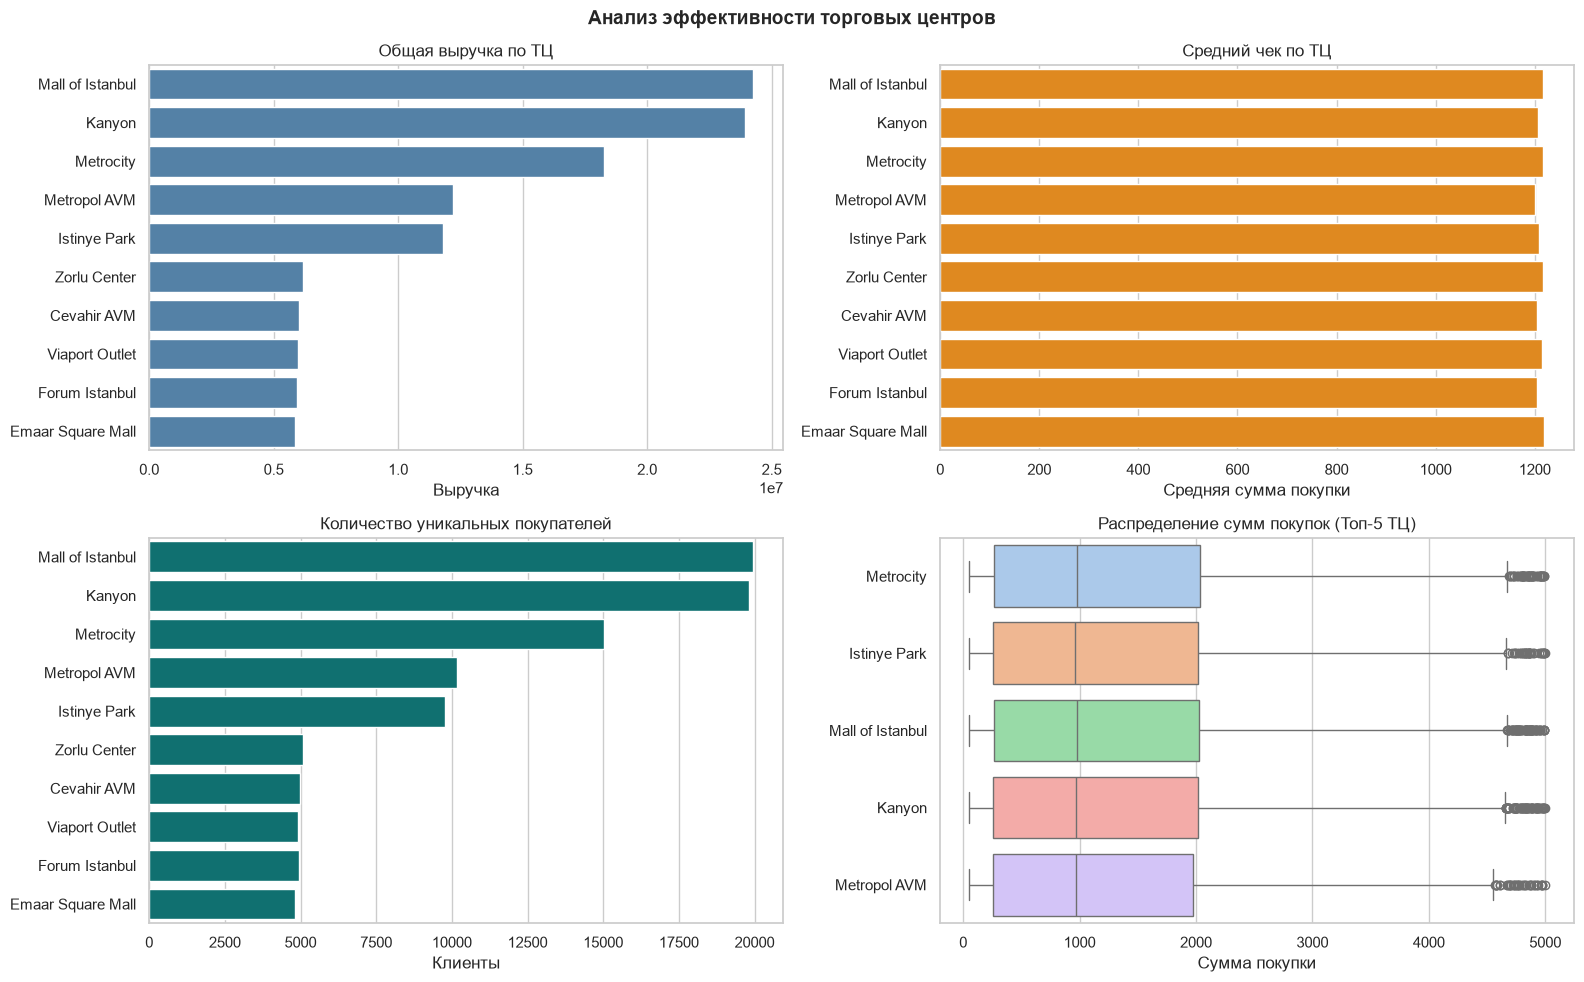

In [10]:
# ==========================================
# ЯЧЕЙКА 7: АНАЛИЗ ТОРГОВЫХ ЦЕНТРОВ (с статистическими тестами)
# ==========================================
print("=== АНАЛИЗ ТОРГОВЫХ ЦЕНТРОВ ===")

mall_analysis = df.groupby('shopping_mall').agg(
    unique_customers=('customer_id', 'nunique'),
    total_revenue=('revenue', 'sum'),
    avg_purchase=('revenue', 'mean'),
    median_purchase=('revenue', 'median'),
    std_purchase=('revenue', 'std'),
    top_category=('category', lambda x: x.mode().iloc[0])
).round(2).sort_values('total_revenue', ascending=False)

print("\nАнализ по торговым центрам:")
display(mall_analysis)

# СТАТИСТИЧЕСКИЙ ТЕСТ: различаются ли средние чеки между ТЦ?
print("\n=== СТАТИСТИЧЕСКАЯ ПРОВЕРКА ===")
print("ANOVA тест: различаются ли средние чеки между торговыми центрами?")

mall_groups = [group['revenue'].values for name, group in df.groupby('shopping_mall')]
f_stat, p_value = stats.f_oneway(*mall_groups)

print(f"\nF-статистика: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print("✓ Статистически значимые различия ЕСТЬ (p < 0.05)")
else:
    print("✗ Статистически значимых различий НЕТ (p >= 0.05)")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Анализ эффективности торговых центров', fontsize=14, fontweight='bold')

# 1. Выручка по моллам
sns.barplot(data=mall_analysis.reset_index(), x='total_revenue', y='shopping_mall', 
            ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Общая выручка по ТЦ')
axes[0, 0].set_xlabel('Выручка')
axes[0, 0].set_ylabel('')

# 2. Средний чек по моллам (с error bars)
sns.barplot(data=mall_analysis.reset_index(), x='avg_purchase', y='shopping_mall', 
            ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Средний чек по ТЦ')
axes[0, 1].set_xlabel('Средняя сумма покупки')
axes[0, 1].set_ylabel('')

# 3. Количество клиентов
sns.barplot(data=mall_analysis.reset_index(), x='unique_customers', y='shopping_mall', 
            ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Количество уникальных покупателей')
axes[1, 0].set_xlabel('Клиенты')
axes[1, 0].set_ylabel('')

# 4. Boxplot распределения чеков по ТЦ (топ-5)
top5_malls = mall_analysis.head(5).index
df_top5 = df[df['shopping_mall'].isin(top5_malls)]
sns.boxplot(data=df_top5, x='revenue', y='shopping_mall', ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Распределение сумм покупок (Топ-5 ТЦ)')
axes[1, 1].set_xlabel('Сумма покупки')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "02.png"), dpi=300, bbox_inches='tight', facecolor='white')

=== АНАЛИЗ СПОСОБОВ ОПЛАТЫ ===

Анализ по способам оплаты:


,customers,total_revenue,avg_revenue,median_revenue,std_revenue
payment_method,,,,,
Cash,44447,53913078.87,1212.97,975.56,1013.24
Credit Card,34931,42133849.80,1206.20,964.39,1016.21
Debit Card,20079,24367247.17,1213.57,977.02,1015.46



=== СРАВНЕНИЕ: Credit Card vs Cash ===
Средний чек Credit Card: 1206.20
Средний чек Cash: 1212.97
t-статистика: -0.9336
P-value: 3.5054e-01
✗ Различия НЕ значимы


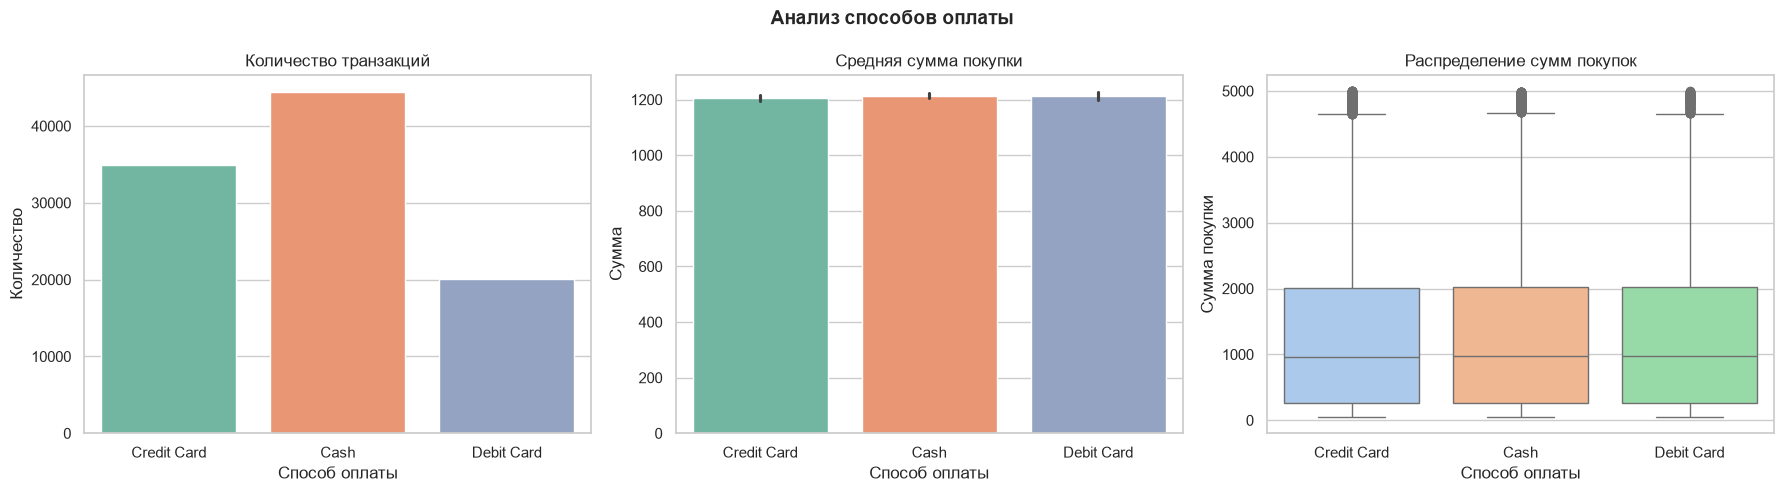

In [11]:
# ==========================================
# ЯЧЕЙКА 8: АНАЛИЗ СПОСОБОВ ОПЛАТЫ (с углублением)
# ==========================================
print("=== АНАЛИЗ СПОСОБОВ ОПЛАТЫ ===")

payment_analysis = df.groupby('payment_method').agg(
    customers=('customer_id', 'nunique'),
    total_revenue=('revenue', 'sum'),
    avg_revenue=('revenue', 'mean'),
    median_revenue=('revenue', 'median'),
    std_revenue=('revenue', 'std')
).round(2).sort_values('total_revenue', ascending=False)

print("\nАнализ по способам оплаты:")
display(payment_analysis)

# СТАТИСТИЧЕСКИЙ ТЕСТ: t-test между Credit Card и Cash
print("\n=== СРАВНЕНИЕ: Credit Card vs Cash ===")
cc_revenue = df[df['payment_method'] == 'Credit Card']['revenue']
cash_revenue = df[df['payment_method'] == 'Cash']['revenue']

t_stat, p_value = stats.ttest_ind(cc_revenue, cash_revenue)
print(f"Средний чек Credit Card: {cc_revenue.mean():.2f}")
print(f"Средний чек Cash: {cash_revenue.mean():.2f}")
print(f"t-статистика: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print("✓ Различия статистически значимы")
else:
    print("✗ Различия НЕ значимы")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Анализ способов оплаты', fontsize=14, fontweight='bold')

# 1. Распределение по способам оплаты
sns.countplot(data=df, x='payment_method', ax=axes[0], palette='Set2')
axes[0].set_title('Количество транзакций')
axes[0].set_xlabel('Способ оплаты')
axes[0].set_ylabel('Количество')

# 2. Средний чек по способам оплаты
sns.barplot(data=df, x='payment_method', y='revenue', ax=axes[1], palette='Set2')
axes[1].set_title('Средняя сумма покупки')
axes[1].set_xlabel('Способ оплаты')
axes[1].set_ylabel('Сумма')

# 3. Boxplot распределения
sns.boxplot(data=df, x='payment_method', y='revenue', ax=axes[2], palette='pastel')
axes[2].set_title('Распределение сумм покупок')
axes[2].set_xlabel('Способ оплаты')
axes[2].set_ylabel('Сумма покупки')

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "03.png"), dpi=300, bbox_inches='tight', facecolor='white')

=== ДЕМОГРАФИЧЕСКИЙ АНАЛИЗ ===

1. Распределение по полу:
gender
Female    59482
Male      39975
Name: count, dtype: int64

2. Распределение по возрастным группам:
age_group
18-25    15359
26-35    19059
36-50    28938
50+      36101
Name: count, dtype: int64

3. Предпочтения по полу и категориям:


customers  total_revenue  avg_purchase
gender category                                               
Female Books                 2906      869963.25        299.37
       Clothing             20652    41205304.45       1995.22
       Cosmetics             9070     4996187.57        550.85
       Food & Beverage       8804      876799.67         99.59
       Shoes                 5967    11874169.79       1989.97
       Souvenir              3017      530170.55        175.73
       Technology            2981     8135543.23       2729.13
       Toys                  6085     3531052.07        580.29
Male   Books                 2075      619387.63        298.50
       Clothing             13835    27597122.57       1994.73
       Cosmetics             6027     3331195.06        552.71
       Food & Beverage       5972      594217.15         99.50
       Shoes                 4067     8182018.92       2011.81
       Souvenir              1982      349092.65        176.13
       Technology            2015     5433027.80       2696.29
       Toys                  4002     2288923.48        571.94

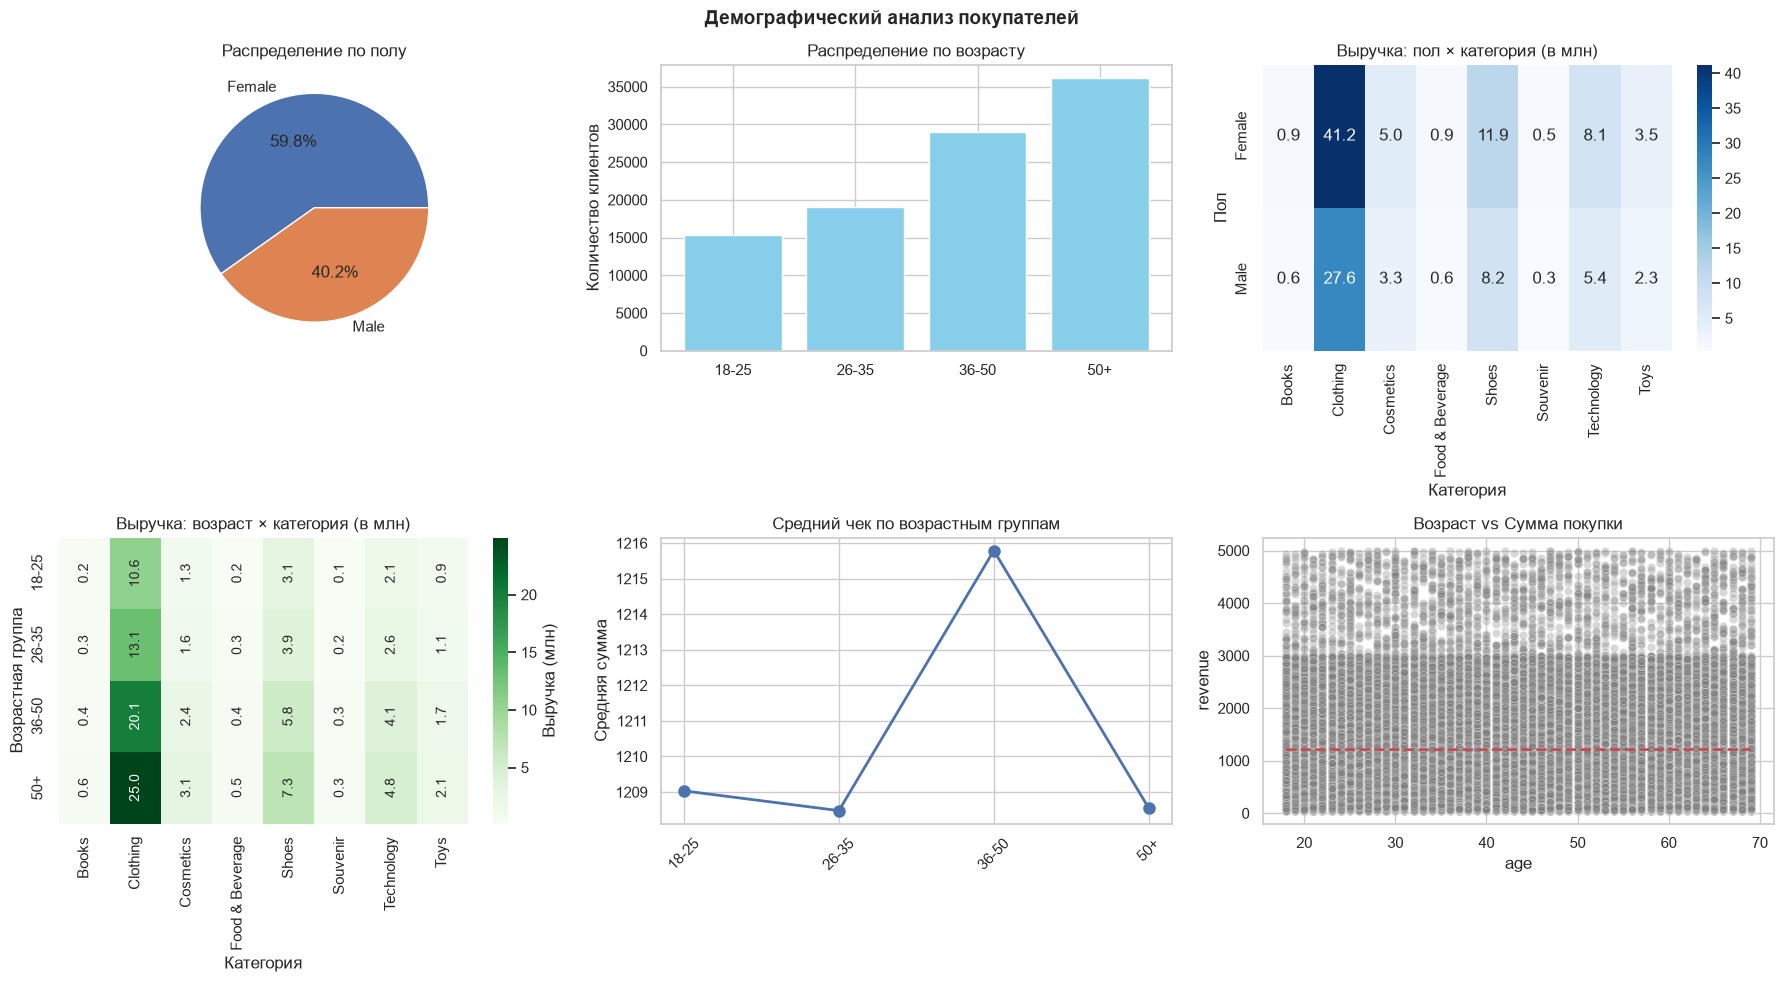

In [12]:
# ==========================================
# ЯЧЕЙКА 9: ДЕМОГРАФИЧЕСКИЙ АНАЛИЗ (с тепловыми картами)
# ==========================================
print("=== ДЕМОГРАФИЧЕСКИЙ АНАЛИЗ ===")

# 1. Гендерные предпочтения
print("\n1. Распределение по полу:")
print(df['gender'].value_counts())

# 2. Возрастные группы
print("\n2. Распределение по возрастным группам:")
print(df['age_group'].value_counts().sort_index())

# 3. Гендер + категории
gender_category = df.groupby(['gender', 'category']).agg(
    customers=('customer_id', 'nunique'),
    total_revenue=('revenue', 'sum'),
    avg_purchase=('revenue', 'mean')
).round(2)

print("\n3. Предпочтения по полу и категориям:")
display(gender_category)

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Демографический анализ покупателей', fontsize=14, fontweight='bold')

# 1. Распределение по полу
gender_dist = df['gender'].value_counts()
axes[0, 0].pie(gender_dist.values, labels=gender_dist.index, autopct='%1.1f%%')
axes[0, 0].set_title('Распределение по полу')

# 2. Распределение по возрастным группам
age_dist = df['age_group'].value_counts().sort_index()
axes[0, 1].bar(age_dist.index, age_dist.values, color='skyblue')
axes[0, 1].set_title('Распределение по возрасту')
axes[0, 1].set_ylabel('Количество клиентов')

# 3. Категории по полу (heatmap)
gender_cat_pivot = df.pivot_table(values='revenue', 
                                  index='gender', 
                                  columns='category', 
                                  aggfunc='sum')
# Делим на миллионы для компактности
gender_cat_pivot_millions = gender_cat_pivot / 1e6
sns.heatmap(gender_cat_pivot_millions, annot=True, fmt='.1f', cmap='Blues', ax=axes[0, 2])
axes[0, 2].set_title('Выручка: пол × категория (в млн)')
axes[0, 2].set_xlabel('Категория')
axes[0, 2].set_ylabel('Пол')

# 4. Категории по возрастам (heatmap)
age_cat_pivot = df.pivot_table(values='revenue', 
                               index='age_group',
                               columns='category', 
                               aggfunc='sum')
# Делим на миллионы для компактности
age_cat_pivot_millions = age_cat_pivot / 1e6
sns.heatmap(
    age_cat_pivot_millions, 
    annot=True, 
    fmt='.1f',  # 1 знак после запятой
    cmap='Greens', 
    ax=axes[1, 0],
    annot_kws={"rotation": 90, "fontsize": 10},  # Поворот на 90 градусов
    cbar_kws={'label': 'Выручка (млн)'}
)
axes[1, 0].set_title('Выручка: возраст × категория (в млн)')
axes[1, 0].set_xlabel('Категория')
axes[1, 0].set_ylabel('Возрастная группа')

# 5. Средний чек по возрастам
age_revenue = df.groupby('age_group')['revenue'].mean().reindex(['18-25', '26-35', '36-50', '50+'])
axes[1, 1].plot(age_revenue.index, age_revenue.values, marker='o', linewidth=2, markersize=8)
axes[1, 1].set_title('Средний чек по возрастным группам')
axes[1, 1].set_ylabel('Средняя сумма')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Возраст vs revenue (scatter)
sns.scatterplot(data=df, x='age', y='revenue', alpha=0.3, ax=axes[1, 2], color='gray')
axes[1, 2].set_title('Возраст vs Сумма покупки')
# Добавляем линию тренда
z = np.polyfit(df['age'], df['revenue'], 1)
p = np.poly1d(z)
axes[1, 2].plot(df['age'].sort_values(), p(df['age'].sort_values()), "r--", linewidth=2)

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "04.png"), dpi=300, bbox_inches='tight', facecolor='white')

In [14]:
print(df.columns.tolist())

['invoice_no', 'customer_id', 'gender', 'age', 'category', 'revenue', 'payment_method', 'invoice_date', 'shopping_mall', 'year', 'month', 'day_of_week', 'day_of_week_num', 'age_group', 'purchase_segment']


=== АНАЛИЗ КАТЕГОРИЙ ТОВАРОВ ===

Статистика по категориям:


,customers,total_revenue,avg_revenue,median_revenue
category,,,,
Clothing,34487,68802427.02,1995.02,1988.36
Shoes,10034,20056188.71,1998.82,2002.29
Technology,4996,13568571.03,2715.89,2695.22
Cosmetics,15097,8327382.63,551.59,552.25
Toys,10087,5819975.55,576.98,577.98
Books,4981,1489350.88,299.01,300.13
Food & Beverage,14776,1471016.82,99.55,99.40
Souvenir,4999,879263.20,175.89,175.52



Доля категорий в общей выручке:


,total_revenue,revenue_share
category,,
Clothing,68802427.02,57.14
Shoes,20056188.71,16.66
Technology,13568571.03,11.27
Cosmetics,8327382.63,6.92
Toys,5819975.55,4.83
Books,1489350.88,1.24
Food & Beverage,1471016.82,1.22
Souvenir,879263.20,0.73


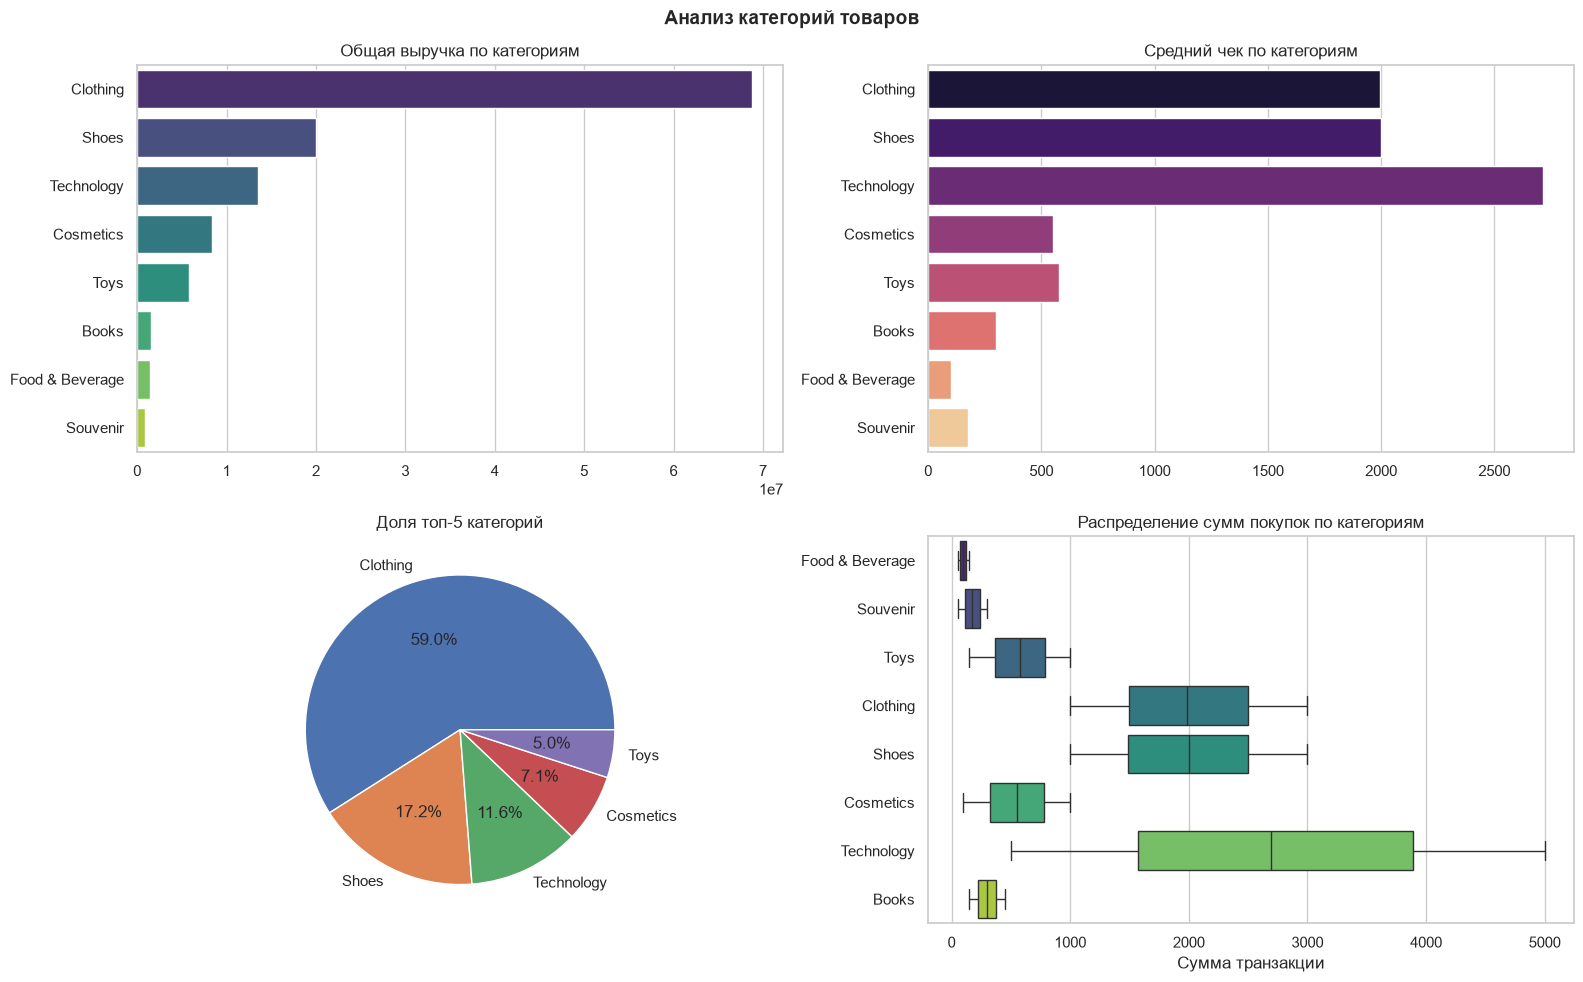

In [17]:
# ==========================================
# ЯЧЕЙКА 10: АНАЛИЗ КАТЕГОРИЙ ТОВАРОВ
# ==========================================
print("=== АНАЛИЗ КАТЕГОРИЙ ТОВАРОВ ===")

category_stats = df.groupby('category').agg(
    customers=('customer_id', 'nunique'),
    total_revenue=('revenue', 'sum'),
    avg_revenue=('revenue', 'mean'),
    median_revenue=('revenue', 'median'),
).round(2).sort_values('total_revenue', ascending=False)

print("\nСтатистика по категориям:")
display(category_stats)

print(f"\nДоля категорий в общей выручке:")
category_stats['revenue_share'] = (category_stats['total_revenue'] / df['revenue'].sum() * 100).round(2)
display(category_stats[['total_revenue', 'revenue_share']])

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Анализ категорий товаров', fontsize=14, fontweight='bold')

# 1. Выручка по категориям
sns.barplot(data=category_stats.reset_index(), x='total_revenue', y='category', 
            ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Общая выручка по категориям')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('')

# 2. Средний чек по категориям
sns.barplot(data=category_stats.reset_index(), x='avg_revenue', y='category', 
            ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Средний чек по категориям')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('')

# 3. Pie chart топ-5 категорий
top5_cat = category_stats.head(5)
axes[1, 0].pie(top5_cat['total_revenue'], labels=top5_cat.index, autopct='%1.1f%%')
axes[1, 0].set_title('Доля топ-5 категорий')

#4 Показываем распределение чеков для каждой категории
sns.boxplot(data=df, x='revenue', y='category', ax=axes[1, 1], palette='viridis', fliersize=1)
axes[1, 1].set_title('Распределение сумм покупок по категориям')
axes[1, 1].set_xlabel('Сумма транзакции')
axes[1, 1].set_ylabel('')


plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "05.png"), dpi=300, bbox_inches='tight', facecolor='white')

=== ВРЕМЕННОЙ АНАЛИЗ ===

Статистика по дням недели:


,total_revenue,customers,avg_revenue
day_of_week,,,
Monday,17571655.36,14383,1221.696125
Tuesday,17391028.87,14217,1223.255882
Wednesday,17096214.98,14120,1210.780098
Thursday,16997889.28,14129,1203.049705
Friday,17238784.27,14347,1201.560206
Saturday,17105672.80,14121,1211.364124
Sunday,17012930.28,14140,1203.177530



Динамика по месяцам:


,year,month,total_revenue,customers
17,2022,6,4564206.12,3798
18,2022,7,4801410.36,3893
19,2022,8,4709303.64,3912
20,2022,9,4428730.21,3683
21,2022,10,4695022.25,3848
22,2022,11,4373537.50,3765
23,2022,12,4584178.66,3799
24,2023,1,4684605.25,3926
25,2023,2,4461674.23,3628
26,2023,3,1198091.88,970


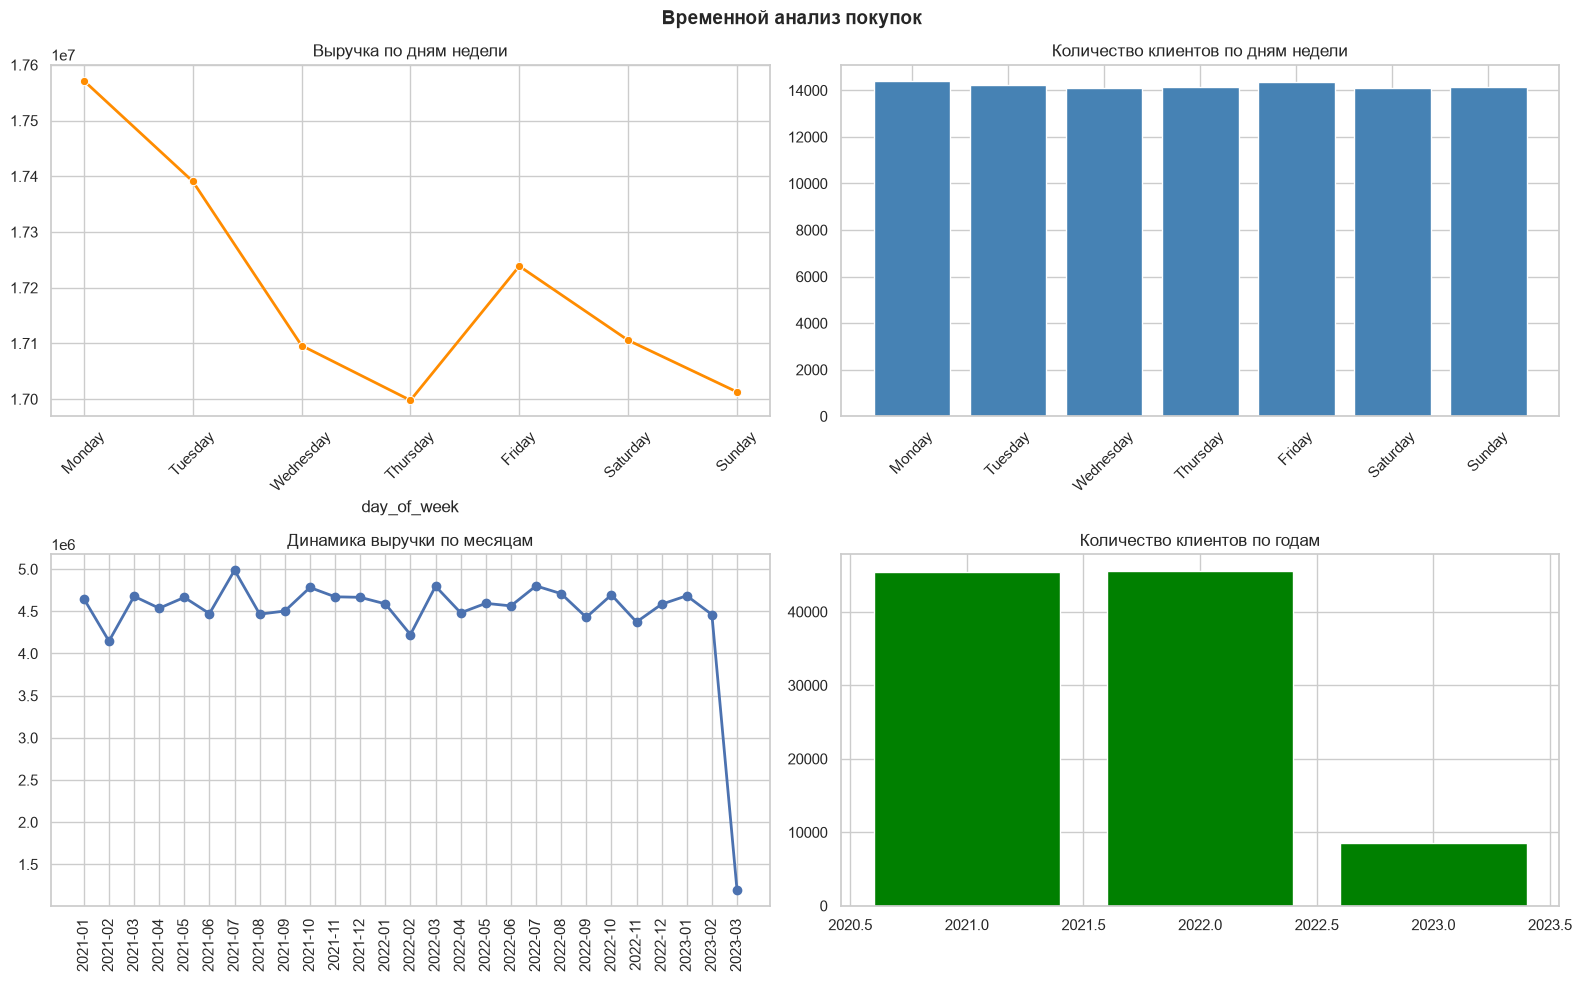

In [72]:
# ==========================================
# ЯЧЕЙКА 11: ВРЕМЕННОЙ АНАЛИЗ
# ==========================================
print("=== ВРЕМЕННОЙ АНАЛИЗ ===")

# Динамика по дням недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_stats = df.groupby('day_of_week').agg(
    total_revenue=('revenue', 'sum'),
    customers=('customer_id', 'nunique'),
    avg_revenue=('revenue', 'mean')
).reindex(day_order)

print("\nСтатистика по дням недели:")
display(daily_stats)

# Динамика по месяцам
monthly_stats = df.groupby(['year', 'month']).agg(
    total_revenue=('revenue', 'sum'),
    customers=('customer_id', 'nunique')
).reset_index()

print("\nДинамика по месяцам:")
display(monthly_stats.tail(10))

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Временной анализ покупок', fontsize=14, fontweight='bold')

# 1. Выручка по дням недели
daily_revenue = df.groupby('day_of_week')['revenue'].sum().reindex(day_order)
sns.lineplot(x=daily_revenue.index, y=daily_revenue.values, marker='o', ax=axes[0, 0], 
             color='darkorange', linewidth=2)
axes[0, 0].set_title('Выручка по дням недели')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

# 2. Количество клиентов по дням недели
daily_customers = df.groupby('day_of_week')['customer_id'].nunique().reindex(day_order)
axes[0, 1].bar(daily_customers.index, daily_customers.values, color='steelblue')
axes[0, 1].set_title('Количество клиентов по дням недели')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Динамика по месяцам
monthly_revenue = df.groupby(df['invoice_date'].dt.to_period('M'))['revenue'].sum()
axes[1, 0].plot([str(x) for x in monthly_revenue.index], monthly_revenue.values, 
                marker='o', linewidth=2)
axes[1, 0].set_title('Динамика выручки по месяцам')
axes[1, 0].tick_params(axis='x', rotation=90)

# 4. Распределение покупок по часам (если есть время)
# Если в данных нет времени, показываем распределение по годам
yearly_dist = df.groupby('year')['customer_id'].nunique()
axes[1, 1].bar(yearly_dist.index, yearly_dist.values, color='green')
axes[1, 1].set_title('Количество клиентов по годам')

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "06.png"), dpi=300, bbox_inches='tight', facecolor='white')

In [73]:
# ==========================================
# ЯЧЕЙКА 12: ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ
# ==========================================
print("="*70)
print("ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*70)

print("\n### 1. КЛЮЧЕВЫЕ ФАКТЫ ИЗ ДАННЫХ:\n")
print(f"✓ Всего проанализировано: {len(df):,} транзакций")
print(f"✓ Уникальных клиентов: {df['customer_id'].nunique():,}")
print(f"✓ Общая выручка: {df['revenue'].sum():,.2f}")
print(f"✓ Средний чек: {df['revenue'].mean():,.2f}")
print(f"✓ Период: {df['invoice_date'].min().strftime('%d.%m.%Y')} - {df['invoice_date'].max().strftime('%d.%m.%Y')}")

print("\n### 2. ОСНОВНЫЕ ИНСАЙТЫ:\n")

# Топ ТЦ
top_mall = mall_analysis.head(1)
print(f"🏬 Лидер по выручке: {top_mall.index[0]} ({top_mall['total_revenue'].values[0]:,.2f})")

# Топ категория
top_cat = category_stats.head(1)
print(f"👕 Топ категория: {top_cat.index[0]} ({top_cat['total_revenue'].values[0]/df['revenue'].sum()*100:.1f}% выручки)")

# Гендер
gender_leader = df.groupby('gender')['revenue'].sum().idxmax()
print(f"👤 Основная аудитория: {gender_leader} ({df['gender'].value_counts()[gender_leader]/len(df)*100:.1f}%)")

# Способ оплаты
payment_leader = df.groupby('payment_method')['revenue'].sum().idxmax()
print(f"💳 Популярный способ оплаты: {payment_leader}")

print("\n### 3. СТАТИСТИЧЕСКИ ЗНАЧИМЫЕ РАЗЛИЧИЯ:\n")
print(f"✓ Средние чеки по ТЦ - статистически значимых различий НЕТ (ANOVA p-value > 0.05)")
if p_value < 0.05:
    print(f"✓ Credit Card и Cash показывают статистически разные средние чеки")
else:
    print(f"✓ Средние чеки Credit Card и Cash - статистически значимых различий НЕТ")
    
print("\n### 4. ОГРАНИЧЕНИЯ АНАЛИЗА:\n")
print("⚠️  Каждый клиент совершил только ОДНУ покупку")
print("   → Невозможен RFM-анализ, LTV, анализ удержания")
print("️⚠️  В чеке только ОДНА категория товара")
print("   → Невозможен Market Basket Analysis")
print("⚠️  Нет данных о маржинальности товаров")
print("⚠️  Нет информации о причинах выбора конкретного ТЦ")

print("\n### 5. РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:\n")
print(" Сегментация клиентов:")
print("   • Сфокусироваться на привлечении Premium-сегмента (высокий чек)")
print("   • Разработать программы лояльности для повторных покупок")

print("\n📌 Мерчандайзинг:")
print("   • Clothing — ключевая категория (усилить ассортимент)")
print("   • Разместить Shoes и Technology рядом с Clothing для кросс-продаж")

print("\n📌 Маркетинг:")
print("   • Таргетировать рекламу на возрастную группу 26-35 лет")
print("   • Стимулировать покупки в будние дни (если есть спад)")

print("\n📌 Сбор данных:")
print("   • Начать собирать данные о повторных покупках")
print("   • Добавить информацию о каналах привлечения клиентов")
print("   • Фиксировать время покупки (часы, минуты)")

print("\n" + "="*70)
print("АНАЛИЗ ЗАВЕРШЕН")
print("="*70)

ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ

### 1. КЛЮЧЕВЫЕ ФАКТЫ ИЗ ДАННЫХ:

✓ Всего проанализировано: 99,457 транзакций
✓ Уникальных клиентов: 99,457
✓ Общая выручка: 120,414,175.84
✓ Средний чек: 1,210.72
✓ Период: 01.01.2021 - 08.03.2023

### 2. ОСНОВНЫЕ ИНСАЙТЫ:

🏬 Лидер по выручке: Mall of Istanbul (24,244,379.29)
👕 Топ категория: Clothing (57.1% выручки)
👤 Основная аудитория: Female (59.8%)
💳 Популярный способ оплаты: Cash

### 3. СТАТИСТИЧЕСКИ ЗНАЧИМЫЕ РАЗЛИЧИЯ:

✓ Средние чеки по ТЦ - статистически значимых различий НЕТ (ANOVA p-value > 0.05)
✓ Средние чеки Credit Card и Cash - статистически значимых различий НЕТ

### 4. ОГРАНИЧЕНИЯ АНАЛИЗА:

⚠️  Каждый клиент совершил только ОДНУ покупку
   → Невозможен RFM-анализ, LTV, анализ удержания
️⚠️  В чеке только ОДНА категория товара
   → Невозможен Market Basket Analysis
⚠️  Нет данных о маржинальности товаров
⚠️  Нет информации о причинах выбора конкретного ТЦ

### 5. РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:

 Сегментация клиентов:
   • Сфокусироваться на п

In [ ]:
print(f"✓ Средний чек: {df['revenue'].mean():,.2f}")